#Import Library


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from mpl_toolkits.mplot3d import Axes3D

In [56]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [57]:
path ="/content/gdrive/MyDrive/Mecine Learning/Praktikum6/data/BankNote_Authentication.csv"

In [58]:
# Menampilkan 5 baris pertama
print("=== 5 Data Teratas ===")
print(df.head())


=== 5 Data Teratas ===
   variance  skewness  curtosis  entropy  class
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0
5   4.36840    9.6718   -3.9606 -3.16250      0


In [59]:
# Informasi dataset
print("\n=== Informasi Dataset ===")
print(df.info())



=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371 entries, 1 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1371 non-null   float64
 1   skewness  1371 non-null   float64
 2   curtosis  1371 non-null   float64
 3   entropy   1371 non-null   float64
 4   class     1371 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None


In [60]:
# Statistik deskriptif
print("\n=== Statistik Deskriptif ===")
print(df.describe())



=== Statistik Deskriptif ===
          variance     skewness     curtosis      entropy        class
count  1371.000000  1371.000000  1371.000000  1371.000000  1371.000000
mean      0.431410     1.917434     1.400694    -1.192200     0.444931
std       2.842494     5.868359     4.310105     2.101683     0.497139
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.774700    -1.711300    -1.553350    -2.417000     0.000000
50%       0.495710     2.313400     0.616630    -0.586650     0.000000
75%       2.814650     6.813100     3.181600     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


In [61]:
# Cek nilai unik dan distribusi kelas
print("\n=== Distribusi Kelas ===")
print(df['class'].value_counts())


=== Distribusi Kelas ===
class
0    761
1    610
Name: count, dtype: int64


#Pemilihan Fitur dan Label

In [62]:
# Memisahkan fitur dan label
X = df.drop('class', axis=1)
y = df['class']

print("Shape fitur (X):", X.shape)
print("Shape label (y):", y.shape)

Shape fitur (X): (1371, 4)
Shape label (y): (1371,)


#Split Data (Training & Testing)

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data latih:", X_train.shape[0])
print("Data uji:", X_test.shape[0])

Data latih: 1096
Data uji: 275


In [64]:
df['class'].unique()

array([0, 1])

In [65]:
df['class'].value_counts()

,count
class,
0,761
1,610


In [66]:
X = df.drop('class', axis=1)   # fiturnya menggunakan semua kolom kecuali 'class'
y = df['class']

In [67]:
X.head()

,variance,skewness,curtosis,entropy
1,4.54590,8.1674,-2.4586,-1.46210
2,3.86600,-2.6383,1.9242,0.10645
3,3.45660,9.5228,-4.0112,-3.59440
4,0.32924,-4.4552,4.5718,-0.98880
5,4.36840,9.6718,-3.9606,-3.16250


In [68]:
y.head()

,class
1,0
2,0
3,0
4,0
5,0


In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVC(kernel='rbf', C=1, gamma='scale')
model.fit(X_train_scaled, y_train)

SVC(C=1)

#Evaluasi

In [70]:
y_pred = model.predict(X_test_scaled)

print("\nAkurasi :", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


Akurasi : 100.0 %

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00       127

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275


Confusion Matrix:
 [[148   0]
 [  0 127]]


#Visualisasi Confusion Matrix


Confusion Matrix:
 [[148   0]
 [  0 127]]


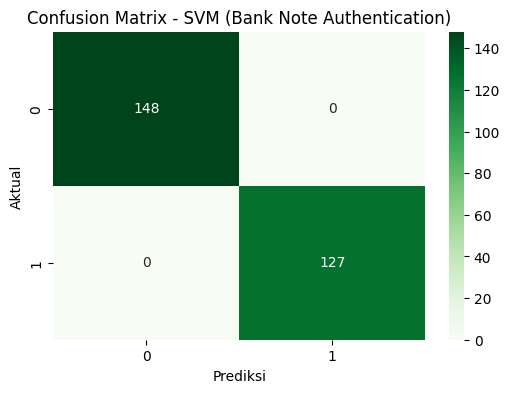

In [71]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='Greens', fmt='d')
plt.title("Confusion Matrix - SVM (Bank Note Authentication)")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

#Visualisasi 3D (pakai 3 fitur utama)

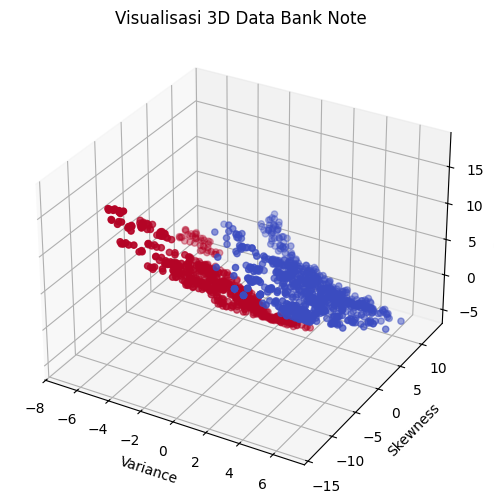

In [72]:
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['variance'], df['skewness'], df['curtosis'], c=df['class'], cmap='coolwarm')
ax.set_xlabel('Variance')
ax.set_ylabel('Skewness')
ax.set_zlabel('Curtosis')
ax.set_title('Visualisasi 3D Data Bank Note')
plt.show()